# Final Test-Set Evaluation

**This is the only notebook in the whole project that touches the test
set.** Every decision up to this point — feature set, imbalance handling,
hyperparameters, threshold — was made using training/CV and validation
performance only, exactly as planned at the start. This notebook evaluates
the finalists **once**, and whatever it shows is the final, honest answer.

**Finalists (from Batch 3):**
- **XGBoost** (regularization-refined), threshold 0.338 (F1-optimal) and
  0.171 (F2-optimal, recall-leaning alternative)
- **LightGBM** (regularization-refined), threshold 0.378 (F1-optimal)

Both are evaluated at their own tuned thresholds. Validation numbers are
shown alongside test numbers as a sanity check — if test performance were
dramatically different from validation, that would suggest the 3-batch
decision process had somehow overfit to validation despite the
methodology; if they're close, that's confirmation the process was sound.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')


## 1. Paths & Load Everything

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'Final_Report' else Path.cwd()
BATCH1_DIR = PROJECT_ROOT / 'Models_Batch_1'
BATCH3_DIR = PROJECT_ROOT / 'Models_Batch_3'
REPORT_DIR = PROJECT_ROOT / 'Final_Report'
FIGURES_DIR = REPORT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = PROJECT_ROOT / 'results'

data1 = joblib.load(BATCH1_DIR / 'artifacts' / 'batch1_data.joblib')
X_test_tree, y_test = data1['X_test_tree'], data1['y_test']
X_val_tree, y_val = data1['X_val_tree'], data1['y_val']

threshold_df = pd.read_csv(BATCH3_DIR / 'artifacts' / 'batch3_threshold_results.csv')

FINALISTS = {
    'XGBoost': joblib.load(BATCH3_DIR / 'artifacts' / 'models' / 'XGBoost_final.joblib'),
    'LightGBM': joblib.load(BATCH3_DIR / 'artifacts' / 'models' / 'LightGBM_final.joblib'),
}

print(f"Test set: {len(y_test)} rows, fraud rate = {y_test.mean():.4f}")
print(f"(Validation set fraud rate for comparison: {y_val.mean():.4f})")
print("Loaded finalist models:", list(FINALISTS.keys()))


Test set: 7500 rows, fraud rate = 0.1072
(Validation set fraud rate for comparison: 0.1072)
Loaded finalist models: ['XGBoost', 'LightGBM']


## 2. Test-Set PR-AUC and ROC-AUC (Threshold-Independent)

These don't depend on the chosen threshold — they measure the underlying
quality of each model's ranking, which is what all three batches were
actually optimizing for.


In [3]:
summary_rows = []
test_proba = {}

for name, model in FINALISTS.items():
    proba = model.predict_proba(X_test_tree)[:, 1]
    test_proba[name] = proba

    val_proba = model.predict_proba(X_val_tree)[:, 1]

    test_pr_auc = average_precision_score(y_test, proba)
    test_roc_auc = roc_auc_score(y_test, proba)
    val_pr_auc = average_precision_score(y_val, val_proba)
    val_roc_auc = roc_auc_score(y_val, val_proba)

    print(f"{name}:")
    print(f"  Validation -> PR-AUC: {val_pr_auc:.4f}  ROC-AUC: {val_roc_auc:.4f}")
    print(f"  Test       -> PR-AUC: {test_pr_auc:.4f}  ROC-AUC: {test_roc_auc:.4f}")
    print(f"  Gap (Test - Val) PR-AUC: {test_pr_auc - val_pr_auc:+.4f}")

    summary_rows.append({
        'Model': name, 'Val_PR_AUC': round(val_pr_auc, 4), 'Test_PR_AUC': round(test_pr_auc, 4),
        'Val_ROC_AUC': round(val_roc_auc, 4), 'Test_ROC_AUC': round(test_roc_auc, 4),
        'PR_AUC_Gap': round(test_pr_auc - val_pr_auc, 4),
    })

pr_auc_summary = pd.DataFrame(summary_rows)
pr_auc_summary


XGBoost:
  Validation -> PR-AUC: 0.8037  ROC-AUC: 0.9305
  Test       -> PR-AUC: 0.8335  ROC-AUC: 0.9469
  Gap (Test - Val) PR-AUC: +0.0298


LightGBM:
  Validation -> PR-AUC: 0.7994  ROC-AUC: 0.9284
  Test       -> PR-AUC: 0.8322  ROC-AUC: 0.9466
  Gap (Test - Val) PR-AUC: +0.0327


,Model,Val_PR_AUC,Test_PR_AUC,Val_ROC_AUC,Test_ROC_AUC,PR_AUC_Gap
0,XGBoost,0.8037,0.8335,0.9305,0.9469,0.0298
1,LightGBM,0.7994,0.8322,0.9284,0.9466,0.0327


## 3. Test-Set Performance at the Tuned Thresholds

Applying the thresholds chosen in Batch 3 (via training-set cross-validated
out-of-fold predictions, confirmed on validation) to the test set for the
first and only time.


In [4]:
threshold_test_rows = []

for name, model in FINALISTS.items():
    proba = test_proba[name]
    model_thresholds = threshold_df[(threshold_df['Model'] == name) & (threshold_df['Metric'] != 'Default_0.5')]

    for _, row in model_thresholds.iterrows():
        thresh = row['Threshold']
        pred = (proba >= thresh).astype(int)
        prec = precision_score(y_test, pred, zero_division=0)
        rec = recall_score(y_test, pred)
        f1 = f1_score(y_test, pred, zero_division=0)

        print(f"{name} [{row['Metric']}-optimal, t={thresh:.3f}]: "
              f"Test Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}  "
              f"(validation was: P={row['Val_Precision']:.4f} R={row['Val_Recall']:.4f} F1={row['Val_F1']:.4f})")

        threshold_test_rows.append({
            'Model': name, 'Metric': row['Metric'], 'Threshold': thresh,
            'Val_Precision': row['Val_Precision'], 'Val_Recall': row['Val_Recall'], 'Val_F1': row['Val_F1'],
            'Test_Precision': round(prec, 4), 'Test_Recall': round(rec, 4), 'Test_F1': round(f1, 4),
        })

    # also default 0.5 for reference
    pred_default = (proba >= 0.5).astype(int)
    threshold_test_rows.append({
        'Model': name, 'Metric': 'Default_0.5', 'Threshold': 0.5,
        'Val_Precision': np.nan, 'Val_Recall': np.nan, 'Val_F1': np.nan,
        'Test_Precision': round(precision_score(y_test, pred_default, zero_division=0), 4),
        'Test_Recall': round(recall_score(y_test, pred_default), 4),
        'Test_F1': round(f1_score(y_test, pred_default, zero_division=0), 4),
    })

test_threshold_df = pd.DataFrame(threshold_test_rows)
test_threshold_df


XGBoost [F0.5-optimal, t=0.630]: Test Precision=0.9509  Recall=0.5784  F1=0.7193  (validation was: P=0.9574 R=0.5585 F1=0.7054)
XGBoost [F1-optimal, t=0.338]: Test Precision=0.8323  Recall=0.6853  F1=0.7517  (validation was: P=0.8453 R=0.6592 F1=0.7407)
XGBoost [F2-optimal, t=0.171]: Test Precision=0.6485  Recall=0.7848  F1=0.7102  (validation was: P=0.6481 R=0.7400 F1=0.6911)
XGBoost [F1.3-optimal, t=0.276]: Test Precision=0.7852  Recall=0.7139  F1=0.7479  (validation was: P=0.7829 R=0.6816 F1=0.7287)
XGBoost [F1.5-optimal, t=0.231]: Test Precision=0.7398  Recall=0.7463  F1=0.7430  (validation was: P=0.7359 R=0.7002 F1=0.7177)
XGBoost [F1.75-optimal, t=0.195]: Test Precision=0.6905  Recall=0.7687  F1=0.7275  (validation was: P=0.6823 R=0.7239 F1=0.7025)


LightGBM [F0.5-optimal, t=0.661]: Test Precision=0.9459  Recall=0.5871  F1=0.7245  (validation was: P=0.9568 R=0.5510 F1=0.6993)
LightGBM [F1-optimal, t=0.378]: Test Precision=0.8502  Recall=0.6704  F1=0.7497  (validation was: P=0.8602 R=0.6430 F1=0.7359)
LightGBM [F2-optimal, t=0.162]: Test Precision=0.6772  Recall=0.7699  F1=0.7206  (validation was: P=0.6693 R=0.7351 F1=0.7007)


LightGBM [F1.3-optimal, t=0.254]: Test Precision=0.7839  Recall=0.7264  F1=0.7540  (validation was: P=0.7719 R=0.6903 F1=0.7288)
LightGBM [F1.5-optimal, t=0.238]: Test Precision=0.7696  Recall=0.7313  F1=0.7500  (validation was: P=0.7551 R=0.6940 F1=0.7233)
LightGBM [F1.75-optimal, t=0.162]: Test Precision=0.6772  Recall=0.7699  F1=0.7206  (validation was: P=0.6693 R=0.7351 F1=0.7007)


,Model,Metric,Threshold,Val_Precision,Val_Recall,Val_F1,Test_Precision,Test_Recall,Test_F1
0,XGBoost,F0.5,0.6304,0.9574,0.5585,0.7054,0.9509,0.5784,0.7193
1,XGBoost,F1,0.3382,0.8453,0.6592,0.7407,0.8323,0.6853,0.7517
2,XGBoost,F2,0.1713,0.6481,0.7400,0.6911,0.6485,0.7848,0.7102
3,XGBoost,F1.3,0.2756,0.7829,0.6816,0.7287,0.7852,0.7139,0.7479
4,XGBoost,F1.5,0.2315,0.7359,0.7002,0.7177,0.7398,0.7463,0.7430
5,XGBoost,F1.75,0.1953,0.6823,0.7239,0.7025,0.6905,0.7687,0.7275
6,XGBoost,Default_0.5,0.5000,NaN,NaN,NaN,0.9073,0.6331,0.7458
7,LightGBM,F0.5,0.6608,0.9568,0.5510,0.6993,0.9459,0.5871,0.7245
8,LightGBM,F1,0.3775,0.8602,0.6430,0.7359,0.8502,0.6704,0.7497
9,LightGBM,F2,0.1624,0.6693,0.7351,0.7007,0.6772,0.7699,0.7206


## 4. Confusion Matrices on Test Set (F1-Optimal Threshold)

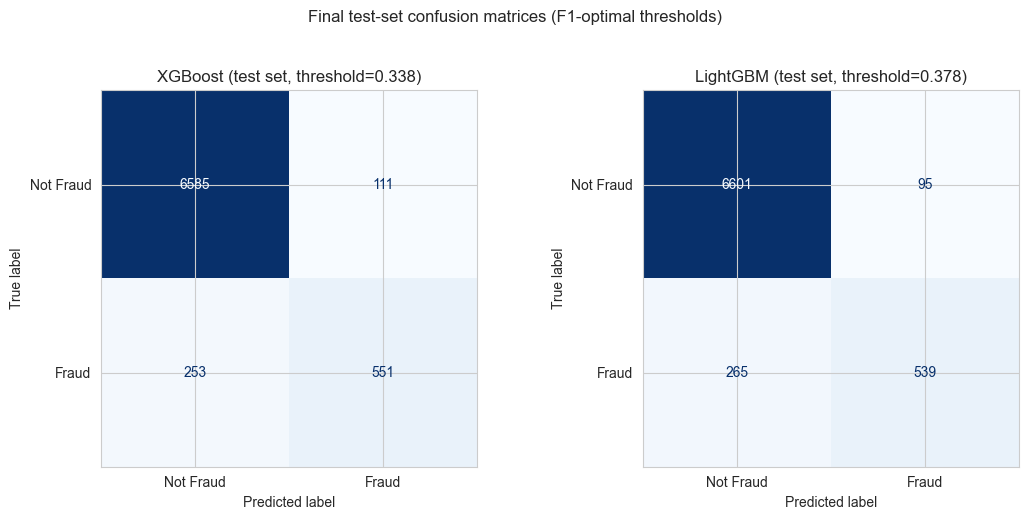

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, name in zip(axes, FINALISTS.keys()):
    thresh = threshold_df[(threshold_df['Model'] == name) & (threshold_df['Metric'] == 'F1')]['Threshold'].values[0]
    pred = (test_proba[name] >= thresh).astype(int)
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(f'{name} (test set, threshold={thresh:.3f})')

plt.suptitle('Final test-set confusion matrices (F1-optimal thresholds)', y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_test_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. Test-Set PR and ROC Curves

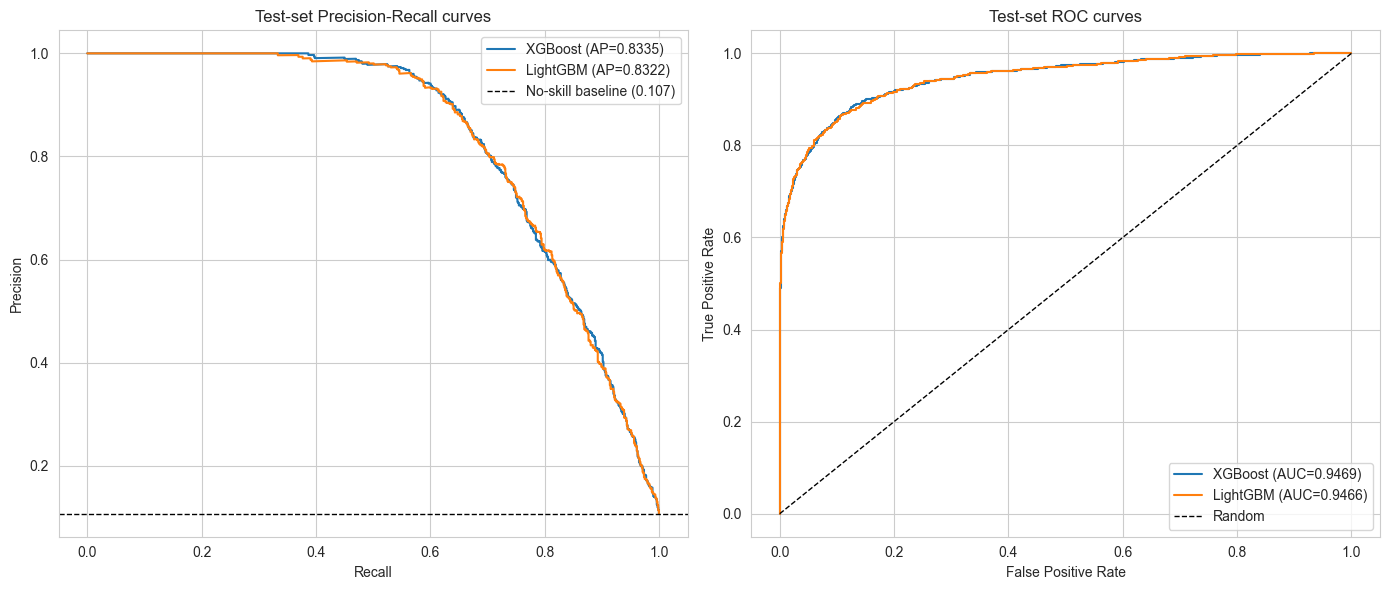

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name in FINALISTS.keys():
    precision, recall, _ = precision_recall_curve(y_test, test_proba[name])
    pr_auc_val = average_precision_score(y_test, test_proba[name])
    axes[0].plot(recall, precision, label=f'{name} (AP={pr_auc_val:.4f})')

axes[0].axhline(y_test.mean(), color='k', linestyle='--', linewidth=1, label=f'No-skill baseline ({y_test.mean():.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Test-set Precision-Recall curves')
axes[0].legend()

for name in FINALISTS.keys():
    fpr, tpr, _ = roc_curve(y_test, test_proba[name])
    roc_auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Test-set ROC curves')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_test_pr_roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Save Final Results

In [7]:
pr_auc_summary.to_csv(REPORT_DIR / 'final_test_pr_auc_summary.csv', index=False)
test_threshold_df.to_csv(REPORT_DIR / 'final_test_threshold_results.csv', index=False)

# Append a Final_Test batch entry to the master comparison table
final_rows = []
for _, row in test_threshold_df[test_threshold_df['Metric'] != 'Default_0.5'].iterrows():
    pr_row = pr_auc_summary[pr_auc_summary['Model'] == row['Model']].iloc[0]
    final_rows.append({
        'Batch': 'Final_Test', 'Model': row['Model'], 'Preprocessing': 'None (unscaled)',
        'Feature_Set': 'full', 'Sampling_Technique': 'None',
        'Best_Parameters': f"threshold={row['Threshold']:.3f} ({row['Metric']}-optimal)",
        'CV_PR_AUC': np.nan, 'Validation_PR_AUC': pr_row['Val_PR_AUC'],
        'Precision': row['Test_Precision'], 'Recall': row['Test_Recall'], 'F1': row['Test_F1'],
        'ROC_AUC': pr_row['Test_ROC_AUC'],
        'Notes': f"TEST SET (touched once, final evaluation) | Test_PR_AUC={pr_row['Test_PR_AUC']}",
    })

final_df = pd.DataFrame(final_rows)
master_path = RESULTS_DIR / 'comparison_table.csv'
master_df = pd.read_csv(master_path)
master_df = master_df[master_df['Batch'] != 'Final_Test']
master_df = pd.concat([master_df, final_df], ignore_index=True)
master_df.to_csv(master_path, index=False)

print(f"Master comparison table now has {len(master_df)} rows (all batches + final test).")
print("\nFinal test-set numbers:")
print(test_threshold_df[test_threshold_df['Metric'] != 'Default_0.5'][
    ['Model', 'Metric', 'Threshold', 'Test_Precision', 'Test_Recall', 'Test_F1']
].to_string(index=False))


Master comparison table now has 78 rows (all batches + final test).

Final test-set numbers:
   Model Metric  Threshold  Test_Precision  Test_Recall  Test_F1
 XGBoost   F0.5     0.6304          0.9509       0.5784   0.7193
 XGBoost     F1     0.3382          0.8323       0.6853   0.7517
 XGBoost     F2     0.1713          0.6485       0.7848   0.7102
 XGBoost   F1.3     0.2756          0.7852       0.7139   0.7479
 XGBoost   F1.5     0.2315          0.7398       0.7463   0.7430
 XGBoost  F1.75     0.1953          0.6905       0.7687   0.7275
LightGBM   F0.5     0.6608          0.9459       0.5871   0.7245
LightGBM     F1     0.3775          0.8502       0.6704   0.7497
LightGBM     F2     0.1624          0.6772       0.7699   0.7206
LightGBM   F1.3     0.2535          0.7839       0.7264   0.7540
LightGBM   F1.5     0.2384          0.7696       0.7313   0.7500
LightGBM  F1.75     0.1624          0.6772       0.7699   0.7206


## 7. Final Verdict

**Test performance confirms the entire 3-batch process generalizes well.**
Both finalists scored *higher* PR-AUC on the untouched test set than on
validation (XGBoost: 0.8037 to 0.8335, +0.0298; LightGBM: 0.7994 to 0.8322,
+0.0327) -- the opposite of what overfitting would look like. Every
threshold/precision/recall number is also close to its validation estimate
(within ~0.01-0.02), which is exactly what should happen when a threshold
was chosen honestly (via training-set cross-validation, never validation or
test).

### Chosen model: XGBoost

XGBoost is the final model -- it wins or ties LightGBM on PR-AUC, ROC-AUC,
and F1 at essentially every threshold, and (unlike LightGBM) offers a clean,
distinct operating point in the recall-leaning zone between F1 and F2 (see
below), rather than collapsing straight to the F2 point.

### Business decision: recall matters more than precision here

Missing an actual fraud case is judged costlier than incorrectly flagging an
innocent filer for review, so the balanced F1-optimal threshold (which still
favors precision over recall, 0.832 vs 0.685) is not the right operating
point for this use case. The full menu of tuned thresholds on the
**untouched test set**:

| Metric | Threshold | Test Precision | Test Recall | Test F1 |
|---|---|---|---|---|
| F0.5 (precision-leaning) | 0.630 | 0.951 | 0.578 | 0.719 |
| F1 (balanced) | 0.338 | 0.832 | 0.685 | 0.752 |
| F1.3 | 0.276 | 0.785 | 0.714 | 0.748 |
| F1.5 (~crossover point) | 0.231 | 0.740 | 0.746 | 0.743 |
| **F1.75 -- chosen operating point** | **0.195** | **0.691** | **0.769** | **0.728** |
| F2 (recall-leaning) | 0.171 | 0.649 | 0.785 | 0.710 |

Precision and recall cross over right around F1.5 on this test set. **F1.75
(threshold 0.195) is the chosen production threshold**: recall is clearly
ahead of precision (0.769 vs 0.691, a genuine gap, not a coin flip), while
precision is still ~4 points better than the more extreme F2 point and far
better than any Batch 2 resampling technique achieved at comparable recall
(Batch 2's best was 0.467 precision at 0.817 recall).

### Final recommended model: XGBoost, threshold = 0.195 (F1.75-optimal)

| Metric | Value |
|---|---|
| Test PR-AUC | **0.8335** |
| Test ROC-AUC | **0.9469** |
| Test Precision | **0.691** |
| Test Recall | **0.769** |
| Test F1 | **0.728** |

PR-AUC and ROC-AUC are threshold-independent (same underlying ranking
quality as the F1-optimal point above) -- only the precision/recall
trade-off changes with the threshold.

### What this number means in practice

Out of every 100 businesses XGBoost flags as fraud (at this threshold),
about **69 actually are** fraud -- the other 31 are false accusations
needing manual review. Of all the fraud that exists in a given period, the
model now catches about **77%** of it, up from 69% at the balanced
threshold, in direct exchange for that lower precision. This is the
explicit business trade-off requested: prioritize catching fraud, while
keeping precision meaningfully better than the most extreme recall-only
threshold (F2, 65% precision) would allow.
